<a href="https://colab.research.google.com/github/S-r-i-s-h-a/BankruptcyPrediction/blob/main/Bankruptency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df  = pd.read_csv('/content/drive/MyDrive/ksr_python/ML/Dataset.csv')

In [3]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
list(df.columns)

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Non-industry income and expenditure/revenue',
 ' Continuous interest rate (after tax)',
 ' Operating Expense Rate',
 ' Research and development expense rate',
 ' Cash flow rate',
 ' Interest-bearing debt interest rate',
 ' Tax rate (A)',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Persistent EPS in the Last Four Seasons',
 ' Cash Flow Per Share',
 ' Revenue Per Share (Yuan ¥)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' After-tax Net Profit Growth Rate',
 ' Regular Net Profit Growth Rate',
 ' C

In [5]:
df['Bankrupt?'].value_counts(normalize=True) * 100

,proportion
Bankrupt?,
0,96.77372
1,3.22628


Imbalence Ratio

In [6]:
non_bank = df['Bankrupt?'].value_counts()[0]
bank = df['Bankrupt?'].value_counts()[1]
ratio = non_bank/bank
ratio

np.float64(29.995454545454546)

ibalence ratio is severe

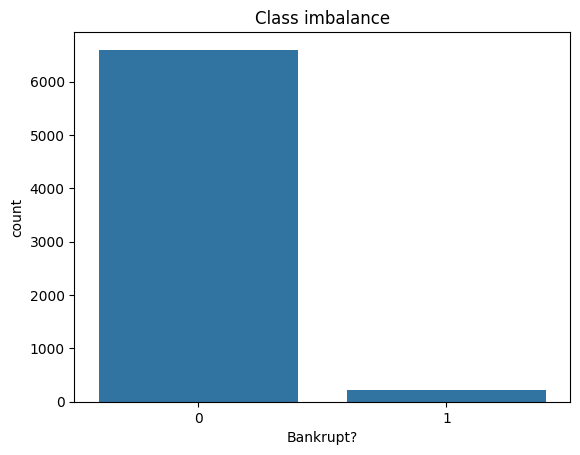

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Bankrupt?',data=df)
plt.title('Class imbalance')
plt.show()

Feature distribution

drop bankurpt coloumn as it is required only for class imbalance

In [8]:
x = df.drop(columns=['Bankrupt?'])
summ_df = x.describe().T.reset_index(names = 'cols')

In [9]:
summ_df

,cols,count,mean,std,min,25%,50%,75%,max
0,ROA(C) before interest and depreciation befor...,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
1,ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
2,ROA(B) before interest and depreciation after...,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
3,Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
4,Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
...,...,...,...,...,...,...,...,...,...
90,Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
91,Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
92,Interest Coverage Ratio (Interest expense to ...,6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
93,Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Checking the range, 75 percentile and skew to flag outliers

In [10]:
skew_df = x.skew().reset_index().rename(columns={'index': 'cols', 0: 'skew'})

In [11]:
skew_df

,cols,skew
0,ROA(C) before interest and depreciation befor...,-0.323941
1,ROA(A) before interest and % after tax,-1.033727
2,ROA(B) before interest and depreciation after...,-0.763564
3,Operating Gross Margin,-8.043368
4,Realized Sales Gross Margin,-8.066572
...,...,...
90,Liability to Equity,27.459467
91,Degree of Financial Leverage (DFL),45.724197
92,Interest Coverage Ratio (Interest expense to ...,-13.939528
93,Net Income Flag,0.000000


In [12]:
summ_df = summ_df.merge(skew_df,how ='left',on='cols')

In [13]:
summ_df['range'] = summ_df['max'] - summ_df['min']
summ_df['max_to_Q3'] = summ_df['max']/summ_df['75%']

In [14]:
summ_df

,cols,count,mean,std,min,25%,50%,75%,max,skew,range,max_to_Q3
0,ROA(C) before interest and depreciation befor...,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0,-0.323941,1.0,1.867195
1,ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0,-1.033727,1.0,1.697340
2,ROA(B) before interest and depreciation after...,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0,-0.763564,1.0,1.712021
3,Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0,-8.043368,1.0,1.628892
4,Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0,-8.066572,1.0,1.629083
...,...,...,...,...,...,...,...,...,...,...,...,...
90,Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0,27.459467,1.0,3.553039
91,Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0,45.724197,1.0,37.156510
92,Interest Coverage Ratio (Interest expense to ...,6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0,-13.939528,1.0,1.767644
93,Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0,0.000000,0.0,1.000000


Getting highly skewed values

In [15]:
len(summ_df[abs(summ_df['skew'])>2])

73

In [16]:
len(summ_df[summ_df['max_to_Q3']>10])

28

Now start Bivariate Analysis

In [17]:
class_means = df.groupby('Bankrupt?').mean().T
class_means = class_means.reset_index(names=['Bankrupt?'])

In [18]:
class_means.columns

Index(['Bankrupt?', 0, 1], dtype='object', name='Bankrupt?')

Calculate absolute mean difference

In [19]:
class_means['difference'] = abs(class_means[1] - class_means[0])
class_means.sort_values(by='difference', ascending=False).head(15)

Bankrupt?,Bankrupt?,0,1,difference
48,Fixed Assets Turnover Frequency,9.756574e+08,1.996603e+09,1.020945e+09
28,Total Asset Growth Rate,5.531603e+09,4.803017e+09,7.285860e+08
71,Quick Asset Turnover Rate,2.147829e+09,2.640836e+09,4.930069e+08
11,Research and development expense rate,1.961923e+09,1.605623e+09,3.562993e+08
73,Cash Turnover Rate,2.481653e+09,2.181733e+09,2.999205e+08
58,Cash/Current Liability,2.989953e+07,2.549409e+08,2.250414e+08
70,Current Asset Turnover Rate,1.189712e+09,1.380154e+09,1.904424e+08
10,Operating Expense Rate,1.998943e+09,1.887486e+09,1.114569e+08
86,Total assets to GNP price,1.621670e+07,9.100000e+07,7.478330e+07
29,Net Value Growth Rate,2.045765e+05,4.240909e+07,4.220451e+07


The scale of values are too large so correlation between deppendant and independant variable will be good

In [20]:
corr_df = df.corr()['Bankrupt?'].abs().sort_values(ascending=False)

In [21]:
corr_df.head(15)

,Bankrupt?
Bankrupt?,1.000000
Net Income to Total Assets,0.315457
ROA(A) before interest and % after tax,0.282941
ROA(B) before interest and depreciation after tax,0.273051
ROA(C) before interest and depreciation before interest,0.260807
Net worth/Assets,0.250161
Debt ratio %,0.250161
Persistent EPS in the Last Four Seasons,0.219560
Retained Earnings to Total Assets,0.217779
Net profit before tax/Paid-in capital,0.207857


In [22]:
feat =  corr_df.abs().sort_values(ascending = False)[1:6].index
feat

Index([' Net Income to Total Assets',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' ROA(C) before interest and depreciation before interest',
       ' Net worth/Assets'],
      dtype='object')

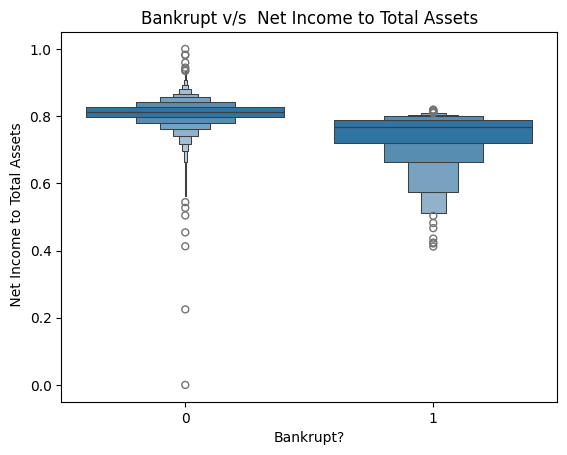

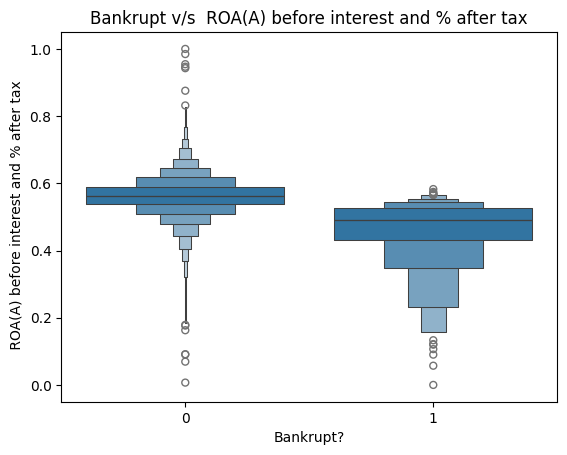

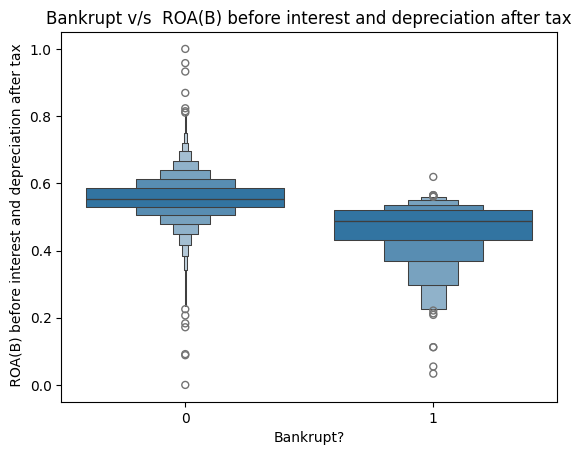

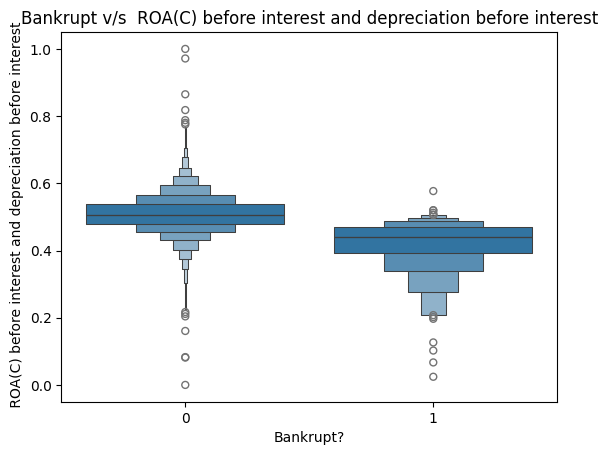

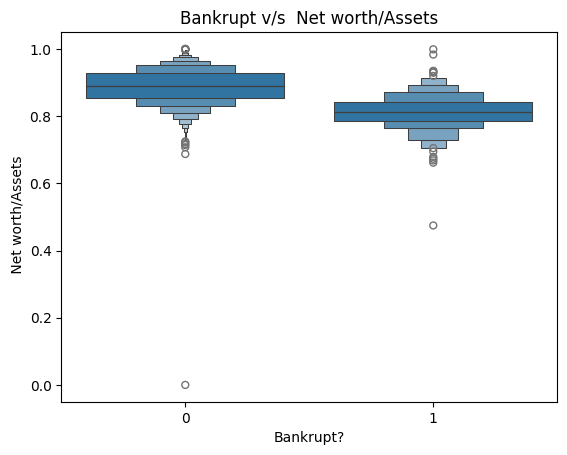

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in feat:
  sns.boxenplot(data = df, x = 'Bankrupt?', y = col)
  plt.title(f'Bankrupt v/s {col}')
  plt.show()

#Detecting multicollinearity

this is helpful regression models, using the df 'X' which has dependant variable excluded

In [24]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

In [25]:
corr_matrix = X.corr().abs()
corr_matrix

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
ROA(C) before interest and depreciation before interest,1.000000,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,...,0.887670,0.071725,0.008135,0.334721,0.274287,0.143629,0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,0.940124,1.000000,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,...,0.961552,0.098900,0.011463,0.326971,0.291744,0.141039,0.011515,0.013372,NaN,0.057887
ROA(B) before interest and depreciation after tax,0.986849,0.955741,1.000000,0.333749,0.331755,0.035212,0.053726,0.049952,0.022366,0.052261,...,0.912040,0.089088,0.007523,0.333750,0.280617,0.142838,0.014663,0.011473,NaN,0.056430
Operating Gross Margin,0.334719,0.326969,0.333749,1.000000,0.999518,0.005745,0.032493,0.027175,0.051438,0.029430,...,0.300143,0.022672,0.004205,1.000000,0.075304,0.085434,0.011806,0.001167,NaN,0.120029
Realized Sales Gross Margin,0.332755,0.324956,0.331755,0.999518,1.000000,0.005610,0.032232,0.026851,0.051242,0.029166,...,0.298155,0.022750,0.004038,0.999518,0.074891,0.085407,0.011268,0.001158,NaN,0.120196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,0.143629,0.141039,0.142838,0.085434,0.085407,0.001541,0.004043,0.004390,0.011899,0.002996,...,0.159697,0.021982,0.003724,0.085434,0.791836,1.000000,0.002119,0.001487,NaN,0.159654
Degree of Financial Leverage (DFL),0.016575,0.011515,0.014663,0.011806,0.011268,0.000935,0.000855,0.000927,0.000556,0.000774,...,0.010463,0.001881,0.008812,0.011806,0.000093,0.002119,1.000000,0.016513,NaN,0.016739
Interest Coverage Ratio (Interest expense to EBIT),0.010573,0.013372,0.011473,0.001167,0.001158,0.000393,0.000984,0.000957,0.001024,0.000798,...,0.012746,0.000239,0.001027,0.001169,0.005147,0.001487,0.016513,1.000000,NaN,0.008339
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


consider only upper triangle fo the matrix to avoid redundancy

In [26]:
import numpy as np
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [27]:
upper

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
ROA(C) before interest and depreciation before interest,NaN,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,...,0.887670,0.071725,0.008135,0.334721,0.274287,0.143629,0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,NaN,NaN,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,...,0.961552,0.098900,0.011463,0.326971,0.291744,0.141039,0.011515,0.013372,NaN,0.057887
ROA(B) before interest and depreciation after tax,NaN,NaN,NaN,0.333749,0.331755,0.035212,0.053726,0.049952,0.022366,0.052261,...,0.912040,0.089088,0.007523,0.333750,0.280617,0.142838,0.014663,0.011473,NaN,0.056430
Operating Gross Margin,NaN,NaN,NaN,NaN,0.999518,0.005745,0.032493,0.027175,0.051438,0.029430,...,0.300143,0.022672,0.004205,1.000000,0.075304,0.085434,0.011806,0.001167,NaN,0.120029
Realized Sales Gross Margin,NaN,NaN,NaN,NaN,NaN,0.005610,0.032232,0.026851,0.051242,0.029166,...,0.298155,0.022750,0.004038,0.999518,0.074891,0.085407,0.011268,0.001158,NaN,0.120196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002119,0.001487,NaN,0.159654
Degree of Financial Leverage (DFL),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016513,NaN,0.016739
Interest Coverage Ratio (Interest expense to EBIT),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008339
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
high_corr_feature = [col for col in upper.columns if any(upper[col] >0.85)]
high_corr_feature

[' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Realized Sales Gross Margin',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Continuous interest rate (after tax)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Regular Net Profit Growth Rate',
 ' Net worth/Assets',
 ' Operating profit/Paid-in capital',
 ' Net profit before tax/Paid-in capital',
 ' Operating Funds to Liability',
 ' Current Liabilities/Equity',
 ' Cash Flow to Sales',
 ' Current Liability to Liability',
 ' Current Liability to Equity',
 ' Net Income to Total Assets',
 ' Gross Profit to Sales',
 ' Liability to Equity']

In [29]:
corr_df_sorted = corr_df.abs().sort_values(ascending=False)
strong_features = corr_df_sorted[corr_df_sorted > 0.02].index

actually some features have good correlation with target variable but as they belong to similar class the correlation between variables of similar class is good which is not acceptable for logistic regression so it's better to have one variable from that particular class

In [30]:
selected = []
threshold = 0.85

for feature in strong_features:
    if feature == 'Bankrupt?':
        continue

    if all(abs(X[feature].corr(X[sel])) < threshold for sel in selected):
        selected.append(feature)

In [31]:
x_cleaned = x[selected]

In [32]:
x_cleaned

,Net Income to Total Assets,Net worth/Assets,Persistent EPS in the Last Four Seasons,Retained Earnings to Total Assets,Current Liability to Assets,Working Capital to Total Assets,Net Income to Stockholder's Equity,Borrowing dependency,Current Liability to Current Assets,Net Value Per Share (A),...,Cash Flow to Liability,Revenue per person,After-tax Net Profit Growth Rate,Total assets to GNP price,Quick Asset Turnover Rate,Quick Ratio,Research and development expense rate,Interest-bearing debt interest rate,Net Worth Turnover Rate (times),Current Liabilities/Liability
0,0.716845,0.792424,0.169141,0.903225,0.147308,0.672775,0.827890,0.390284,0.118250,0.147950,...,0.458609,0.034164,0.688979,0.009219,6.550000e+09,0.001208,0.000000e+00,7.250725e-04,0.032903,0.676269
1,0.795297,0.828824,0.208944,0.931065,0.056963,0.751111,0.839969,0.376760,0.047775,0.182251,...,0.459001,0.006889,0.689693,0.008323,7.700000e+09,0.004039,0.000000e+00,6.470647e-04,0.025484,0.308589
2,0.774670,0.792484,0.180581,0.909903,0.098162,0.829502,0.836774,0.379093,0.025346,0.177911,...,0.459254,0.028997,0.689463,0.040003,1.022676e-03,0.005348,2.550000e+07,7.900790e-04,0.013387,0.446027
3,0.739555,0.848535,0.193722,0.906902,0.098715,0.725754,0.834697,0.379743,0.067250,0.154187,...,0.448518,0.015463,0.689110,0.003252,6.050000e+09,0.002896,0.000000e+00,4.490449e-04,0.028065,0.615848
4,0.795016,0.893491,0.212537,0.913850,0.110195,0.751822,0.839973,0.375025,0.047725,0.167502,...,0.454411,0.058111,0.689697,0.003878,5.050000e+09,0.003727,0.000000e+00,6.860686e-04,0.040161,0.975007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0.799927,0.875382,0.216602,0.925611,0.103838,0.817769,0.840359,0.373823,0.027951,0.175045,...,0.458639,0.006348,0.689778,0.000466,1.244230e-04,0.005457,4.500000e+09,1.790179e-04,0.027903,0.786888
6815,0.799748,0.900747,0.216697,0.932629,0.089901,0.793387,0.840306,0.372505,0.031470,0.181324,...,0.459058,0.016083,0.689734,0.001959,1.173396e-04,0.006741,1.440000e+09,2.370237e-04,0.027419,0.849898
6816,0.797778,0.961061,0.210929,0.932000,0.024414,0.866047,0.840138,0.369637,0.007542,0.269521,...,0.452465,0.022097,0.689202,0.002840,1.749713e-04,0.035112,1.039086e-04,0.000000e+00,0.022419,0.553964
6817,0.811808,0.913021,0.228326,0.939613,0.083199,0.832340,0.841084,0.369649,0.022916,0.213392,...,0.471313,0.012749,0.696113,0.002837,1.351937e-04,0.007256,2.510000e+09,2.110211e-04,0.027258,0.893241


After multicollinearity analysis the less important features are removed and now the number of features are reduced to 45 from 96

#Data Splitting and Class Balancing

function which has all part of pipline for spplitting the model, traing and evaluating the metrics

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix,precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
def model_pipeline(
    X,y,model,
    model_name = 'model',
    scale = False,
    use_smote = False,
    test_size = 0.2,
    random_state = 42):
  X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=test_size,
                                                   stratify=y,random_state=random_state)
  steps = []
  if scale:
    steps.append(('scale',StandardScaler()))
  if use_smote:
    steps.append(('smote',SMOTE(random_state=random_state)))
  steps.append(('model',model))

  pipeline = Pipeline(steps)
  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = cm.ravel()
  results = {
        "Model": model_name,
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "False Negatives": fn,
        "True Positives": tp,
        "False Positives": fp,
        "True Negatives": tn
    }

  return pipeline, pd.DataFrame([results])


##checking for df in which collinearity is removed manually

In [34]:
X_manual = x_cleaned.copy()
y = df['Bankrupt?']

###Logistic regression

In [35]:
from sklearn.linear_model import LogisticRegression
logi = LogisticRegression(max_iter = 1000,class_weight="balanced")
model_log, result_log = model_pipeline( X_manual,y,
                                       model = logi,
                                       model_name = "Logistic Regression",
                                       scale = True,use_smote = True)
result_log

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Logistic Regression,0.795455,0.188172,0.304348,0.882698,9,35,151,1169


Good recall score, but as imbalence is being corrected twice once by using balanced in model and again applying smote so now results should be compared by different combinations

In [36]:
logi_None = LogisticRegression(max_iter = 1000,class_weight=None) # trying with class balance = None
model_log, result_log_w_o_balance = model_pipeline( X_manual,y,
                                       model = logi_None,
                                       model_name = "Logistic Regression not balanced",
                                       scale = True,use_smote = True)
result_log_w_o_balance


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Logistic Regression not balanced,0.795455,0.188172,0.304348,0.882698,9,35,151,1169


The recall is sameThis means smote has a significant effect in reducing class imbalence

###KNN Now

In [37]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.neighbors import KNeighborsClassifier
#trying by consider 5 neighbours for now
knn_manual, res_knn_manual = model_pipeline(
    X_manual, y,
    model=KNeighborsClassifier(n_neighbors=5),
    model_name="KNN (Manual)",
    scale=True,
    use_smote=True
)

res_knn_manual

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,KNN (Manual),0.704545,0.197452,0.308458,0.898094,13,31,126,1194


recall is less compared to logistic regression now tune the model using n_neighbous

In [38]:
from sklearn.model_selection import train_test_split

X_tr,X_tes,y_tr,y_tes = train_test_split(X_manual,y,test_size = 0.2,stratify = y,random_state=42)


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ('scale',StandardScaler()),
    ('smote',SMOTE(random_state=42)),
    ('model',KNeighborsClassifier())

])


In [40]:
param_grid = {
    'model__n_neighbors': range(3, 21, 2)
}
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    knn_pipeline,
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid.fit(X_tr, y_tr)

print("Best k:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

Best k: {'model__n_neighbors': 19}
Best CV Recall: 0.7733333333333333


In [41]:
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_tes)

from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score

cm = confusion_matrix(y_tes, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Test Recall:", recall_score(y_tes, y_pred))
print("Test Precision:", precision_score(y_tes, y_pred))
print("Test F1:", f1_score(y_tes, y_pred))
print("Test Accuracy:", accuracy_score(y_tes, y_pred))
print("FN:", fn)
print("Confusion Matrix:\n", cm)
cm = confusion_matrix(y_tes, y_pred)
tn, fp, fn, tp = cm.ravel()

res_knn_tuned = pd.DataFrame([{
    "Model": "KNN Tuned (Manual)",
    "Recall": recall_score(y_tes, y_pred),
    "Precision": precision_score(y_tes, y_pred),
    "F1": f1_score(y_tes, y_pred),
    "Accuracy": accuracy_score(y_tes, y_pred),
    "False Negatives": fn,
    "True Positives": tp,
    "False Positives": fp,
    "True Negatives": tn
}])

res_knn_tuned

Test Recall: 0.8636363636363636
Test Precision: 0.1557377049180328
Test F1: 0.2638888888888889
Test Accuracy: 0.844574780058651
FN: 6
Confusion Matrix:
 [[1114  206]
 [   6   38]]


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,KNN Tuned (Manual),0.863636,0.155738,0.263889,0.844575,6,38,206,1114


Recall is more than the previous model but precision is less

###Decision tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_manual, res_dt_manual = model_pipeline(
    X_manual, y,
    model=DecisionTreeClassifier(random_state=42),
    model_name="Decision Tree (Manual)",
    scale=False,
    use_smote=True
)

res_dt_manual

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Decision Tree (Manual),0.477273,0.230769,0.311111,0.931818,23,21,70,1250


recall is very low compared to KNN, it is lesser even than the baseline one so it is probably not worth it to fine tune

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_manual, res_rf_manual = model_pipeline(
    X_manual, y,
    model=RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    model_name="Random Forest (Manual)",
    scale=False,
    use_smote=True
)

res_rf_manual

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Random Forest (Manual),0.636364,0.41791,0.504505,0.959677,16,28,39,1281


try fine tuning the model

In [44]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV
# from imblearn.pipeline import Pipeline

# x_tr,x_tes,y_tr,y_tes = train_test_split(X_manual,y,test_size=0.2,stratify=y,random_state = 42)
# rf_pipeline = Pipeline([
#     ('smote',SMOTE(random_state=42)),
#     ('model',RandomForestClassifier(random_state =42))
# ])
# rf_params_grid = {
#     'model__n_estimators' : [200,300],
#     'model__max_depth' : [None,10,20],
#     'model__min_samples_split' : [2,5] ,
#     'model__min_samples_leaf':[1,3]
# }

In [45]:
# grid_rf = GridSearchCV(estimator = rf_pipeline,
#                        param_grid = rf_params_grid,
#                        scoring = 'recall',cv=5, n_jobs =-1)
# grid_rf.fit(x_tr,y_tr)
# print("Best Params:", grid_rf.best_params_)
# print("Best CV Recall:", grid_rf.best_score_)

In [46]:
# best_rf = grid_rf.best_estimator_
# y_pred_rf = best_rf.predict(X_tes)

# from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score

# cm = confusion_matrix(y_tes, y_pred_rf)
# tn, fp, fn, tp = cm.ravel()

# print("Test Recall:", recall_score(y_tes, y_pred_rf))
# print("Test Precision:", precision_score(y_tes, y_pred_rf))
# print("FN:", fn)
# print("Confusion Matrix:\n", cm)

###Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

gb_manual, res_gb_manual = model_pipeline(
    X_manual, y,
    model=GradientBoostingClassifier(random_state=42),
    model_name="Gradient Boosting (Manual)",
    scale=False,
    use_smote=True
)

res_gb_manual

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Gradient Boosting (Manual),0.636364,0.264151,0.373333,0.931085,16,28,78,1242


###Ensembling

In [52]:
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(
    [
        ('knn',best_knn),
        ('log',LogisticRegression(max_iter=1000)),
        ('GB',GradientBoostingClassifier(random_state=42))
    ]

)
voting_model.fit(X_tr,y_tr)
results_ensemble = {
    "Model": "Voting Ensemble",
    "Recall": recall_score(y_tes, y_pred),
    "Precision": precision_score(y_tes, y_pred),
    "F1": f1_score(y_tes, y_pred),
    "Accuracy": accuracy_score(y_tes, y_pred),
    "False Negatives": fn,
    "True Positives": tp,
    "False Positives": fp,
    "True Negatives": tn
}

results_ensemble = pd.DataFrame([results_ensemble])
results_ensemble

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Voting Ensemble,0.863636,0.155738,0.263889,0.844575,6,38,206,1114


###Leaderboards

In [53]:
manual_results = pd.concat([
    result_log,
    res_knn_manual,
    res_knn_tuned,
    res_dt_manual,
    res_gb_manual,
    results_ensemble
], ignore_index=True)

manual_results.sort_values(by="Recall", ascending=False)

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
5,Voting Ensemble,0.863636,0.155738,0.263889,0.844575,6,38,206,1114
2,KNN Tuned (Manual),0.863636,0.155738,0.263889,0.844575,6,38,206,1114
0,Logistic Regression,0.795455,0.188172,0.304348,0.882698,9,35,151,1169
1,KNN (Manual),0.704545,0.197452,0.308458,0.898094,13,31,126,1194
4,Gradient Boosting (Manual),0.636364,0.264151,0.373333,0.931085,16,28,78,1242
3,Decision Tree (Manual),0.477273,0.230769,0.311111,0.931818,23,21,70,1250


Among manually selected feature models, Tuned KNN achieved the highest recall (0.86) with the lowest false negatives (6). Since missing a bankrupt company is more costly than flagging a healthy one, KNN Tuned was selected as the best-performing model under the defined business objective(Minimize Type-2 errors).

In [54]:
len(x.columns)

95

In [55]:
x_vif = x.copy()


In [69]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Copy feature matrix
x_vif = X_manual.copy()

# Function to compute VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Features'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Iteratively remove features with VIF > 10
while True:
    vif_data = calculate_vif(x_vif)
    max_vif = vif_data['VIF'].max()
    if max_vif > 10:
        drop_feat = vif_data.sort_values('VIF', ascending=False).iloc[0]['Features']
        print(f"Dropping {drop_feat} with VIF={max_vif:.2f}")
        x_vif = x_vif.drop(columns=[drop_feat])
    else:
        break

print(f"Remaining features: {x_vif.shape[1]}")

Dropping  Working Capital to Total Assets with VIF=95997.93
Dropping  Borrowing dependency with VIF=6618.08
Dropping  Working Capital/Equity with VIF=38439.94
Dropping  Net worth/Assets with VIF=4491.66
Dropping  Gross Profit to Sales with VIF=2098.26
Dropping  Cash Flow to Equity with VIF=1200.55
Dropping  Cash Reinvestment % with VIF=1028.99
Dropping  Cash Flow to Liability with VIF=595.35
Dropping  Cash Flow to Total Assets with VIF=288.86
Dropping  Operating profit per person with VIF=206.09
Dropping  Current Liabilities/Liability with VIF=31.80
Dropping  Current Assets/Total Assets with VIF=29.36
Dropping  Quick Assets/Total Assets with VIF=13.85
Dropping  Current Liability to Assets with VIF=12.10
Dropping  Total Asset Turnover with VIF=11.43
Remaining features: 30


In [ ]:
len(x_vif.columns)

Features reduced significantly compared to the manual fearure reduction

Check using KNN and logistic regression as they erformed better for manual one

In [75]:
from sklearn.linear_model import LogisticRegression

log_vif = LogisticRegression(max_iter=1000)
mod_log , res_log_vif = model_pipeline(
    x_vif,y,model = log_vif,
    model_name = 'Logistic Regression (VIF)',
    scale = True,
    use_smote = True
)
len(x_vif.columns)

30

In [76]:
res_log_vif

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,Logistic Regression (VIF),0.795455,0.159817,0.26616,0.858504,9,35,184,1136


After reducing the feature set from 95 to 30 using VIF, Logistic Regression maintained the same recall (~0.795), ensuring we still catch most bankrupt companies. Precision dropped slightly due to fewer features providing discriminative power, but the model is now more stable and interpretable

###KNN (BASELINE)

In [78]:
from sklearn.neighbors import KNeighborsClassifier
knn_vif, result_knn_vif = model_pipeline(x_vif,y,model = KNeighborsClassifier(n_neighbors=20), #considerig 20 hoing more neighbours might increase recall
                                         model_name = 'KNN VIF Baseline',
                                         scale = True,
                                         use_smote = True)


In [79]:
result_knn_vif

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,KNN VIF Baseline,0.863636,0.149606,0.255034,0.837243,6,38,216,1104


After reducing features from 95 to 30 using VIF, KNN baseline maintained the same recall (0.8636) and FN (6), which is our primary metric. Precision dropped slightly because some redundant features that helped distinguish healthy companies were removed. This shows that VIF-based reduction keeps recall intact while stabilizing the model.

In [81]:
vif_results_df = pd.concat([res_log_vif,result_knn_vif])

In [85]:
vif_results_df.sort_values('Recall',ascending=False)

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
0,KNN VIF Baseline,0.863636,0.149606,0.255034,0.837243,6,38,216,1104
0,Logistic Regression (VIF),0.795455,0.159817,0.266160,0.858504,9,35,184,1136


So, both mannually removed features and feature removal using VIF have yielded same results

In [90]:
res_df_comb = pd.concat([manual_results,vif_results_df]).sort_values('Recall',ascending=False)

In [91]:
res_df_comb

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives
2,KNN Tuned (Manual),0.863636,0.155738,0.263889,0.844575,6,38,206,1114
5,Voting Ensemble,0.863636,0.155738,0.263889,0.844575,6,38,206,1114
0,KNN VIF Baseline,0.863636,0.149606,0.255034,0.837243,6,38,216,1104
0,Logistic Regression,0.795455,0.188172,0.304348,0.882698,9,35,151,1169
0,Logistic Regression (VIF),0.795455,0.159817,0.266160,0.858504,9,35,184,1136
1,KNN (Manual),0.704545,0.197452,0.308458,0.898094,13,31,126,1194
4,Gradient Boosting (Manual),0.636364,0.264151,0.373333,0.931085,16,28,78,1242
3,Decision Tree (Manual),0.477273,0.230769,0.311111,0.931818,23,21,70,1250


In [97]:
metrics = ["Recall", "Precision", "F1", "Accuracy"]
all_results_melted = res_df_comb.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
)

<Axes: xlabel='Model', ylabel='Value'>

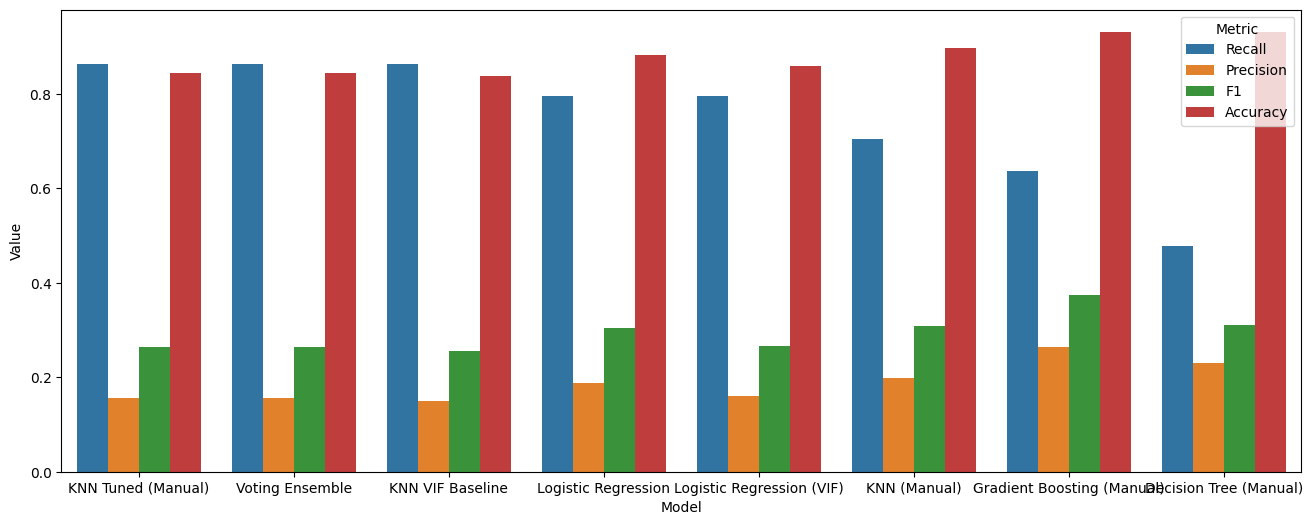

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16,6))
sns.barplot(x='Model',y='Value',hue='Metric', data=all_results_melted
)


Fom these we can conclude that the KNN Model is best fit for the Bankruptcy detection given that in this case we need to reduce the type 2 errors<br>
Also here we need to consider recall as the main evaluation metric as reporting a false negative might result in heavy losses for the investors